# Notebook 15 — Human vs. Machine Label Quality

Evaluates the **returned human labels** from the notebook 14 labeling campaign against
the two machine labelers — the embedding (AIME) labeler and the Haiku labeler — at the
file level and, through the production aggregator, at the repository level. This is
Phase 2 of the notebook 14 design (`notebook14_plan.md`), implemented as a standalone
notebook that starts from the persisted Phase-1 artifacts (`manifest.csv`,
`sampled_repos.csv`, `repo_pool.csv`) plus the raw workbooks the raters actually
returned.

Inputs (as delivered, in `human_labeling/labeled results/`):

- **Rater A** — `pack_raterA_2_labeled (1).xlsx`; added a self-invented `confidence`
  column (reported below, not used).
- **Rater B** — `pack_raterB 2 BMG.numbers` (Apple Numbers, parsed via
  `numbers-parser`); typed the labels into an unnamed 5th column and left `category`
  empty.
- **Rater C** — `pack_raterC 2 (1).xlsx`; added free-text notes in an unnamed 5th
  column (reported below, not used).

S1 normalizes these into the canonical `returned/pack_rater{A,B,C}_filled.xlsx`
files notebook 14 Phase 2 expects (so that notebook stays runnable as designed),
then S2–S6 run the evaluation:

- **S2** — votes matrix, 11-option → collapsed 10-class labels
- **S3** — inter-annotator agreement (Krippendorff's α as the headline statistic —
  it is defined for the 1–3-votes-per-item overlap design; Fleiss' κ on the triple
  block and Cohen's κ per pair as secondary) and reference labels (majority vote /
  single rater; no-majority excluded)
- **S4** — file-level machine-vs-human evaluation: accuracy with Wilson CIs,
  chance-corrected agreement (Cohen's κ vs the reference), class-balanced metrics
  (balanced accuracy, macro/weighted F1), exact McNemar, per-category P/R/F1,
  confusion matrices
- **S4b** — robustness: repo-cluster bootstrap CIs (items are clustered within
  repos), accuracy on majority-vote references only vs single-rater references,
  each-rater-as-truth sensitivity, and rater A's self-reported confidence as an
  auxiliary read
- **S5** — repository maturity three ways through `aggregate_repo_maturity()`:
  exact match, off-by-one, quadratically weighted κ, repo-bootstrap CIs
- **S6** — summary panel & numeric exports (`paper/`: LaTeX tables,
  `summary.json`)

This notebook computes; it does not conclude. Interpretation, paper text, and
limitations live in the hand-written
`notebooks/15_human_label_evaluation_conclusions.md`. The executed run is frozen
as `15. human_label_evaluation.html` next to this notebook.

Caveats carried over from notebook 14: the 35-repo sample is stratified on the
Haiku-derived maturity level, so repo-level match rates are stratum-weighted, not
population rates; per-category file-level metrics only exist for categories present
in these repos.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", None)

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.maturity_scorer import (
    CATEGORY_TO_LEVEL,
    FileClassification,
    aggregate_repo_maturity,
)

DATA = PROJECT_ROOT / "data"
VAL_DIR = DATA / "validation"
FIG_DIR = VAL_DIR / "figures"
HL_DIR = VAL_DIR / "human_labeling"
RESULTS_DIR = HL_DIR / "labeled results"
RETURNED_DIR = HL_DIR / "returned"
RETURNED_DIR.mkdir(exist_ok=True)

RATERS = ["A", "B", "C"]
WL_STEPS = {"tool_standard", "shared_in_tool_folder", "shared_in_root"}
ARTIFACT_CATS = list(CATEGORY_TO_LEVEL.keys())  # 9 leveled categories
NOT_ARTIFACT = "not-artifact"                   # evaluation-time collapse target
CLASSES_10 = ARTIFACT_CATS + [NOT_ARTIFACT]
DROPDOWN = ARTIFACT_CATS + ["general-documentation", "none"]  # 11 rater options
SUMMARY = {}

manifest = pd.read_csv(HL_DIR / "manifest.csv", dtype=str)
repo_table = pd.read_csv(HL_DIR / "sampled_repos.csv")
pool = pd.read_csv(HL_DIR / "repo_pool.csv")

SUMMARY["n_repos_dataset"] = len(pool)
SUMMARY["n_repos_eligible"] = int((pool["label"] == "eligible").sum())
SUMMARY["n_repos_detected"] = int(SUMMARY["n_repos_eligible"]
                                  + (pool["reason"] == "no-strict-november-artifact").sum())
print(f"manifest: {len(manifest)} items across {manifest['repo'].nunique()} repos  |  "
      f"funnel: {SUMMARY['n_repos_dataset']} dataset → "
      f"{SUMMARY['n_repos_detected']} detected → "
      f"{SUMMARY['n_repos_eligible']} eligible")
assert manifest["repo"].nunique() == len(repo_table) == 35

manifest: 195 items across 35 repos  |  funnel: 509 dataset → 392 detected → 268 eligible


## S1. Ingest the raw returns, normalize, write canonical workbooks

Each rater's item set must exactly match their manifest membership (every item whose
repo block contains the rater), every label must be one of the 11 dropdown options,
no duplicates. Rater-specific quirks are normalized here and nowhere else. The
canonical 4-column workbooks are (re)written to `returned/` on every run — they are
derived data; the files in `labeled results/` stay the untouched originals.

In [2]:
from numbers_parser import Document

RAW_RETURNS = {
    "A": RESULTS_DIR / "pack_raterA_2_labeled (1).xlsx",
    "B": RESULTS_DIR / "pack_raterB 2 BMG.numbers",
    "C": RESULTS_DIR / "pack_raterC 2 (1).xlsx",
}
for p in RAW_RETURNS.values():
    assert p.exists(), f"missing raw return: {p}"

# --- Rater A: standard xlsx; extra self-added `confidence` column ---
raw_a = pd.read_excel(RAW_RETURNS["A"], sheet_name="Labels")
assert "confidence" in raw_a.columns
print("rater A self-reported confidence (not used downstream):",
      raw_a["confidence"].value_counts(dropna=False).to_dict())

# --- Rater B: Apple Numbers; labels typed into an unnamed 5th column ---
tbl = Document(RAW_RETURNS["B"]).sheets[0].tables[0]
rows = tbl.rows(values_only=True)
raw_b = pd.DataFrame(rows[1:], columns=list(rows[0]))
raw_b.columns = ["repo", "file", "content", "category_empty", "category"]
assert raw_b["category_empty"].isna().all(), "rater B: dropdown column unexpectedly used"

# --- Rater C: standard xlsx; free-text notes in an unnamed 5th column ---
raw_c = pd.read_excel(RAW_RETURNS["C"], sheet_name="Labels")
c_notes = raw_c[raw_c.columns[4]]
print(f"rater C free-text notes on {int(c_notes.notna().sum())} rows "
      f"(not used downstream), e.g. {c_notes.dropna().unique()[:5].tolist()}")

norm = {}
for r, d in [("A", raw_a), ("B", raw_b), ("C", raw_c)]:
    d = d.copy()
    d["category"] = d["category"].astype(str).str.strip()
    exp = manifest[manifest["assigned_raters"].str.contains(r)]
    assert set(zip(d["repo"], d["file"])) == set(zip(exp["repo"], exp["artifact_path"])), \
        f"rater {r}: item set != manifest membership"
    assert not d.duplicated(subset=["repo", "file"]).any(), f"rater {r}: duplicate rows"
    bad = d[~d["category"].isin(DROPDOWN)]
    assert bad.empty, (f"rater {r}: {len(bad)} invalid/missing labels, "
                       f"e.g. {bad['file'].head(5).tolist()}")
    norm[r] = d[["repo", "file", "content", "category"]].reset_index(drop=True)
    out = RETURNED_DIR / f"pack_rater{r}_filled.xlsx"
    with pd.ExcelWriter(out, engine="openpyxl") as xw:
        norm[r].to_excel(xw, sheet_name="Labels", index=False)
    print(f"rater {r}: {len(d)} rows valid → wrote {out.relative_to(HL_DIR)}")

rater A self-reported confidence (not used downstream): {'High': 48, 'Medium': 32, 'Low': 12}
rater C free-text notes on 7 rows (not used downstream), e.g. ['Specifications/Plans', 'looks like more of rules for c#']
rater A: 92 rows valid → wrote returned/pack_raterA_filled.xlsx
rater B: 86 rows valid → wrote returned/pack_raterB_filled.xlsx
rater C: 92 rows valid → wrote returned/pack_raterC_filled.xlsx


## S2. Votes matrix & collapse

Align on `item_id` via `(repo, artifact_path)` — unique in this November-only sample;
row order is not trusted. Collapse `general-documentation` and `none` →
`not-artifact` (the same 10-class collapse as notebook 13). Under the overlap design
an item carries 1, 2, or 3 votes depending on its repo's block.

In [3]:
def collapse(lab):
    return lab if lab in CATEGORY_TO_LEVEL else NOT_ARTIFACT

path_to_item = manifest.set_index(["repo", "artifact_path"])["item_id"]
assert path_to_item.index.is_unique

votes_raw = pd.DataFrame({
    r: norm[r]
        .assign(item_id=[path_to_item[k] for k in zip(norm[r]["repo"], norm[r]["file"])])
        .set_index("item_id")["category"]
    for r in RATERS
}).reindex(manifest["item_id"])                       # 11-option labels
votes10 = votes_raw.apply(lambda s: s.map(collapse, na_action="ignore"))
n_votes = votes10.notna().sum(axis=1)
exp_votes = (manifest.set_index("item_id")["assigned_raters"].str.len()
             .reindex(votes10.index))
assert n_votes.eq(exp_votes).all(), "votes per item != repo block size"

print(f"ingested {len(votes10)} items; votes per rater:",
      votes_raw.notna().sum().to_dict())
print("items by vote count:", n_votes.value_counts().sort_index().to_dict())
print("\nper-rater collapsed label distribution:")
print(pd.DataFrame({r: votes10[r].value_counts() for r in RATERS})
      .reindex(CLASSES_10).fillna(0).astype(int).to_string())

ingested 195 items; votes per rater: {'A': 92, 'B': 86, 'C': 92}
items by vote count: {1: 128, 2: 59, 3: 8}

per-rater collapsed label distribution:
                A   B   C
rules          27  29  45
configuration   3   2   1
architecture    1   2   0
code-style      7   2   0
agents          8  10   8
commands       21  31  37
skills         10   4   0
flows           9   1   0
session-logs    0   0   1
not-artifact    6   5   0


## S3. Inter-annotator agreement & reference labels (overlap design)

**Krippendorff's α** is the headline agreement statistic: unlike Fleiss' κ it is
defined for varying numbers of raters per item, so it uses *every* multiply-labeled
item (items with a single vote carry no pairable information and drop out by
construction). Reported on the collapsed 10-class labels (the analysis space) and,
secondarily, on the raw 11-option labels. The triple-labeled block additionally
gives **Fleiss' κ** (small n — flagged) and each pair block **Cohen's κ** plus raw
percent agreement.

Reference labels: majority vote where an item has ≥2 votes (an agreeing pair, or
≥2-of-3); the assigned rater's label on unique repos. Split pairs and 3-way splits
get **no reference** — they are excluded from S4/S5 and their counts reported.

In [4]:
import krippendorff
from sklearn.metrics import cohen_kappa_score

# --- Krippendorff's alpha (nominal): raters × items matrix, NaN = not assigned ---
def kripp_alpha(votes, classes):
    to_int = {c: i for i, c in enumerate(classes)}
    rel = votes.apply(lambda s: s.map(to_int, na_action="ignore")).T.to_numpy(dtype=float)
    return krippendorff.alpha(reliability_data=rel, level_of_measurement="nominal")

SUMMARY["kripp_alpha_10"] = kripp_alpha(votes10, CLASSES_10)
SUMMARY["kripp_alpha_11raw"] = kripp_alpha(votes_raw, DROPDOWN)
SUMMARY["n_multivote"] = int((n_votes >= 2).sum())
print(f"Krippendorff's α (nominal, collapsed 10-class) = "
      f"{SUMMARY['kripp_alpha_10']:.3f}  "
      f"[α on raw 11-option labels = {SUMMARY['kripp_alpha_11raw']:.3f}]  "
      f"— computed over the {SUMMARY['n_multivote']} items with ≥2 votes")

def fleiss_kappa(cnt):
    """cnt: items × categories vote-count matrix, constant raters per item."""
    n = int(cnt.sum(axis=1).iloc[0])
    assert (cnt.sum(axis=1) == n).all()
    P_i = ((cnt ** 2).sum(axis=1) - n) / (n * (n - 1))
    p_j = cnt.sum(axis=0) / cnt.values.sum()
    P_bar, P_e = P_i.mean(), (p_j ** 2).sum()
    return (P_bar - P_e) / (1 - P_e)

triple = votes10[n_votes == 3]
cnt = pd.DataFrame({c: (triple == c).sum(axis=1) for c in CLASSES_10})
SUMMARY["fleiss_kappa_triple"] = fleiss_kappa(cnt)
SUMMARY["n_triple"] = len(triple)
unanimous = (triple.nunique(axis=1) == 1).mean()
SUMMARY["unanimous_triple"] = unanimous
print(f"triple-labeled items: {len(triple)}  |  Fleiss' κ = "
      f"{SUMMARY['fleiss_kappa_triple']:.3f}  |  unanimous: {100 * unanimous:.0f}%")
for pair in ("AB", "AC", "BC"):
    a, b = pair
    both = votes10[votes10[a].notna() & votes10[b].notna()]
    agree = (both[a] == both[b]).mean()
    SUMMARY[f"kappa_{pair}"] = cohen_kappa_score(both[a], both[b])
    SUMMARY[f"n_pair_{pair}"] = len(both)
    SUMMARY[f"agree_{pair}"] = agree
    print(f"pair {pair}: {len(both)} shared items  |  raw agreement "
          f"{100 * agree:.1f}%  |  Cohen's κ = {SUMMARY[f'kappa_{pair}']:.3f}")

def ref_of(row):
    v = row.dropna()
    if len(v) == 1:
        return v.iloc[0], f"single-rater-{v.index[0]}"
    top = v.value_counts()
    if top.iloc[0] >= 2:
        return top.index[0], f"majority-{top.iloc[0]}of{len(v)}"
    return np.nan, f"no-majority-{len(v)}votes"

refs = votes10.apply(ref_of, axis=1)
ref_df = pd.DataFrame({
    "item_id": votes10.index,
    "reference": [t[0] for t in refs],
    "ref_source": [t[1] for t in refs],
})
ref_df.to_csv(HL_DIR / "human_labels_reference.csv", index=False)
n_ref = int(ref_df["reference"].notna().sum())
SUMMARY["n_no_majority"] = len(ref_df) - n_ref
print(f"\nreference labels: {n_ref}/{len(ref_df)} items "
      f"({SUMMARY['n_no_majority']} excluded — no majority)")
print("\nreference source breakdown:")
print(ref_df["ref_source"].value_counts().to_string())
print("\nreference label distribution:")
print(ref_df["reference"].value_counts().to_string())

Krippendorff's α (nominal, collapsed 10-class) = 0.572  [α on raw 11-option labels = 0.572]  — computed over the 67 items with ≥2 votes
triple-labeled items: 8  |  Fleiss' κ = 0.839  |  unanimous: 88%
pair AB: 25 shared items  |  raw agreement 76.0%  |  Cohen's κ = 0.649
pair AC: 39 shared items  |  raw agreement 64.1%  |  Cohen's κ = 0.499
pair BC: 19 shared items  |  raw agreement 89.5%  |  Cohen's κ = 0.812



reference labels: 175/195 items (20 excluded — no majority)

reference source breakdown:
ref_source
single-rater-B        50
single-rater-C        42
majority-2of2         39
single-rater-A        36
no-majority-2votes    20
majority-3of3          7
majority-2of3          1

reference label distribution:
reference
commands         73
rules            55
agents           19
not-artifact      8
code-style        6
skills            5
configuration     5
flows             3
architecture      1


## S4. File-level machine-vs-human evaluation

On all items with a reference label: accuracy with Wilson 95% CIs, **Cohen's κ vs
the human reference** (chance-corrected — the class distribution is heavily skewed
toward `commands`/`rules`, so raw accuracy overstates performance), **balanced
accuracy** and **macro/weighted F1** (macro over classes with human support > 0),
exact McNemar on the paired disagreements, per-category precision/recall/F1
(support < 5 flagged), confusion matrices, and the both-machines-wrong failure
list. Machine labels come from the manifest (`label_embedding`, `label_haiku`) and
get the same 10-class collapse (a missing machine label means "no artifact
category" → `not-artifact`).

embedding accuracy vs human: 143/175 = 81.7%  (95% CI 75.3–86.7%)
haiku     accuracy vs human: 142/175 = 81.1%  (95% CI 74.7–86.2%)

embedding  Cohen's κ vs human = 0.743  |  balanced accuracy = 0.514  |  macro F1 = 0.480  |  weighted F1 = 0.808  (macro over the 9 classes with human support > 0)
haiku      Cohen's κ vs human = 0.739  |  balanced accuracy = 0.548  |  macro F1 = 0.525  |  weighted F1 = 0.823  (macro over the 9 classes with human support > 0)

McNemar (exact): emb-only-right=13, haiku-only-right=12, p=1.0000

per-category metrics (human reference as ground truth):
     category  support_human  precision_embedding  recall_embedding  f1_embedding  precision_haiku  recall_haiku  f1_haiku  low_support
        rules             55                0.820             0.909         0.862            0.846         0.800     0.822        False
configuration              5                1.000             1.000         1.000            1.000         1.000     1.000        False
 archit

/Users/pavelazaletskiy/ServerProjects/ai-artifacts/ai-artifacts-analyzer/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


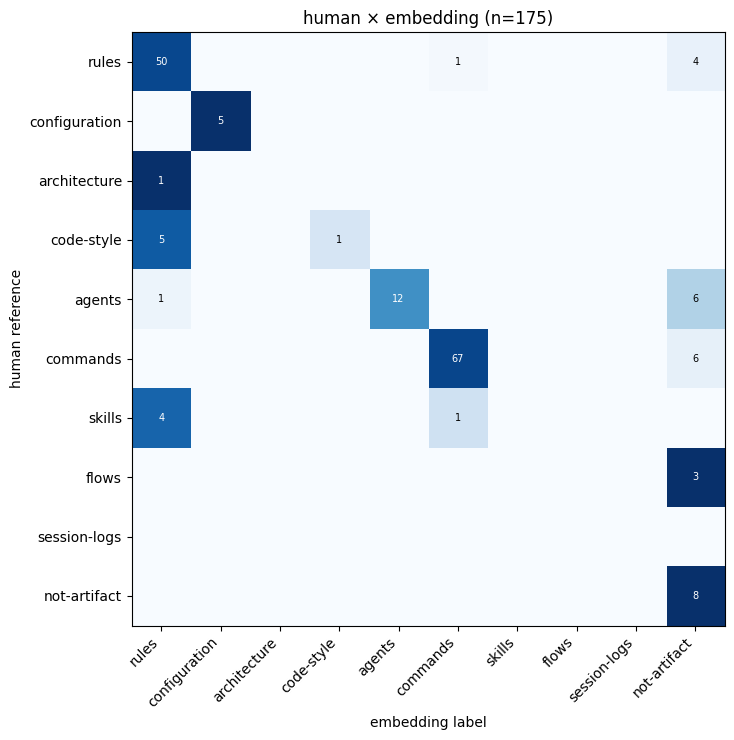

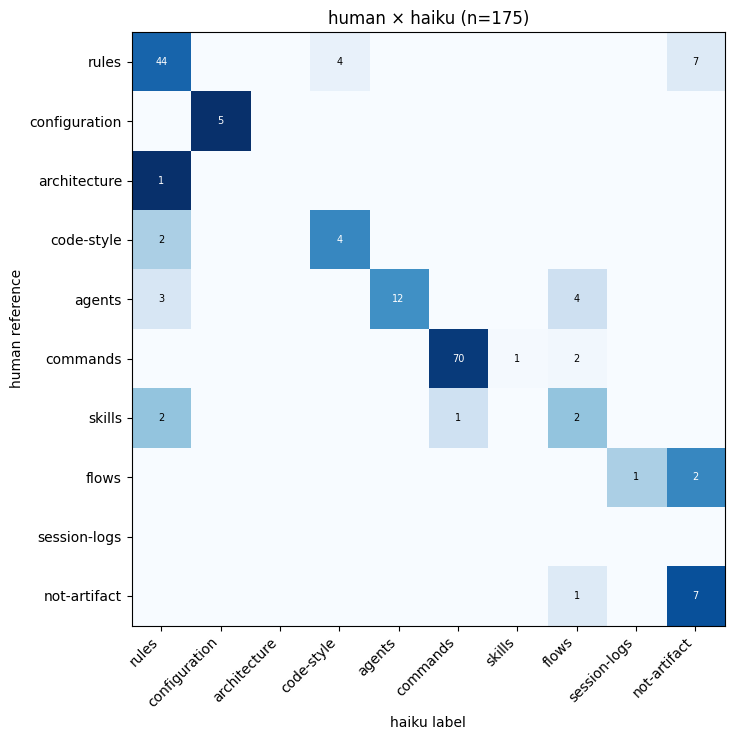


both machines disagree with the human reference — 20 items:
  item_id                                          repo                                                   artifact_path    reference        emb10        llm10     ref_source
item_0025                                  Z3Prover__z3          .github/workflows/agentics/shared/gh-extra-pr-tools.md        rules     commands not-artifact single-rater-B
item_0030                                  Z3Prover__z3                                        .github/workflows/ask.md       agents not-artifact        rules single-rater-B
item_0031                                  Z3Prover__z3                                  .github/workflows/ci-doctor.md       agents not-artifact        flows single-rater-B
item_0032                                  Z3Prover__z3                       .github/workflows/daily-backlog-burner.md       agents not-artifact        flows single-rater-B
item_0033                                  Z3Prover__z3              

In [5]:
from scipy.stats import binomtest
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z ** 2 / n
    centre = (p + z ** 2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / denom
    return (centre - half, centre + half)

ev = manifest.merge(ref_df, on="item_id")
ev = ev[ev["reference"].notna()].copy()
ev["emb10"] = ev["label_embedding"].map(collapse)
ev["llm10"] = ev["label_haiku"].map(collapse)
ev["emb_ok"] = ev["emb10"] == ev["reference"]
ev["llm_ok"] = ev["llm10"] == ev["reference"]

for name, col in (("embedding", "emb_ok"), ("haiku", "llm_ok")):
    k, n = int(ev[col].sum()), len(ev)
    lo, hi = wilson_ci(k, n)
    print(f"{name:9s} accuracy vs human: {k}/{n} = {100 * k / n:.1f}%  "
          f"(95% CI {100 * lo:.1f}–{100 * hi:.1f}%)")
    SUMMARY[f"acc_{name}"] = k / n
    SUMMARY[f"acc_{name}_ci"] = (lo, hi)

from sklearn.metrics import balanced_accuracy_score, f1_score

present = [c for c in CLASSES_10 if (ev["reference"] == c).any()]
print()
for name, col in (("embedding", "emb10"), ("haiku", "llm10")):
    SUMMARY[f"kappa_vs_human_{name}"] = cohen_kappa_score(ev["reference"], ev[col])
    SUMMARY[f"balacc_{name}"] = balanced_accuracy_score(ev["reference"], ev[col])
    SUMMARY[f"macro_f1_{name}"] = f1_score(
        ev["reference"], ev[col], labels=present, average="macro", zero_division=0)
    SUMMARY[f"weighted_f1_{name}"] = f1_score(
        ev["reference"], ev[col], labels=present, average="weighted", zero_division=0)
    print(f"{name:9s}  Cohen's κ vs human = {SUMMARY[f'kappa_vs_human_{name}']:.3f}  |  "
          f"balanced accuracy = {SUMMARY[f'balacc_{name}']:.3f}  |  "
          f"macro F1 = {SUMMARY[f'macro_f1_{name}']:.3f}  |  "
          f"weighted F1 = {SUMMARY[f'weighted_f1_{name}']:.3f}  "
          f"(macro over the {len(present)} classes with human support > 0)")
print()

b = int((ev["emb_ok"] & ~ev["llm_ok"]).sum())   # embedding right, haiku wrong
c = int((~ev["emb_ok"] & ev["llm_ok"]).sum())   # haiku right, embedding wrong
p_mcnemar = binomtest(b, b + c, 0.5).pvalue if b + c else np.nan
print(f"McNemar (exact): emb-only-right={b}, haiku-only-right={c}, "
      f"p={p_mcnemar:.4f}")
SUMMARY["mcnemar_p"] = p_mcnemar
SUMMARY["n_eval"] = len(ev)

tables = {}
for name, col in (("embedding", "emb10"), ("haiku", "llm10")):
    pr, rc, f1, sup = precision_recall_fscore_support(
        ev["reference"], ev[col], labels=CLASSES_10, zero_division=0)
    tables[name] = pd.DataFrame({
        "category": CLASSES_10, "support_human": sup,
        f"precision_{name}": pr.round(3), f"recall_{name}": rc.round(3),
        f"f1_{name}": f1.round(3)})
per_cat_eval = tables["embedding"].merge(
    tables["haiku"].drop(columns="support_human"), on="category")
per_cat_eval["low_support"] = per_cat_eval["support_human"] < 5
per_cat_eval.to_csv(HL_DIR / "human_file_eval.csv", index=False)
print("\nper-category metrics (human reference as ground truth):")
print(per_cat_eval.to_string(index=False))

for name, col in (("embedding", "emb10"), ("haiku", "llm10")):
    cm = pd.DataFrame(confusion_matrix(ev["reference"], ev[col], labels=CLASSES_10),
                      index=pd.Index(CLASSES_10, name="human"),
                      columns=pd.Index(CLASSES_10, name=name))
    share = cm.div(cm.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    fig, ax = plt.subplots(figsize=(9, 7.5))
    ax.imshow(share.values, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(CLASSES_10)), CLASSES_10, rotation=45, ha="right")
    ax.set_yticks(range(len(CLASSES_10)), CLASSES_10)
    for i in range(len(CLASSES_10)):
        for j in range(len(CLASSES_10)):
            if cm.values[i, j]:
                ax.text(j, i, cm.values[i, j], ha="center", va="center",
                        fontsize=7,
                        color="white" if share.values[i, j] > 0.5 else "black")
    ax.set_xlabel(f"{name} label")
    ax.set_ylabel("human reference")
    ax.set_title(f"human × {name} (n={len(ev)})")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"notebook15_confusion_{name}.png", dpi=150)
    plt.show()

fails = ev[~ev["emb_ok"] & ~ev["llm_ok"]]
print(f"\nboth machines disagree with the human reference — {len(fails)} items:")
print(fails[["item_id", "repo", "artifact_path", "reference",
             "emb10", "llm10", "ref_source"]].to_string(index=False))

## S4b. Robustness & sensitivity

Three checks a reviewer will ask for:

1. **Repo-cluster bootstrap** — items are clustered within the 35 repos, so the
   item-i.i.d. Wilson CIs are anti-conservative. Resample the 35 repos with
   replacement (10 000 draws, seed 15) and recompute both accuracies and their
   paired difference.
2. **Reference-strength split** — 128/195 items have a single-rater reference,
   which is noisier than a majority vote. Report accuracy separately on
   majority-vote references and on single-rater references.
3. **Each-rater-as-truth** — bypass the reference construction entirely: score each
   machine against each individual rater over exactly the items that rater labeled.
   The spread across raters bounds how much the reference-construction choice
   matters (and is read against the human–human pairwise agreement from S3).

Auxiliary (descriptive only): rater A self-reported confidence; machine agreement
with A's own labels split by that confidence.

In [6]:
# --- 1. Repo-cluster bootstrap (10k resamples of the 35 repos, seed 15) ---
rng = np.random.default_rng(15)
grp = ev.groupby("repo")
n_r = grp.size().to_numpy()
k_emb = grp["emb_ok"].sum().to_numpy()
k_llm = grp["llm_ok"].sum().to_numpy()
idx = rng.integers(0, len(n_r), size=(10_000, len(n_r)))
acc_e = k_emb[idx].sum(axis=1) / n_r[idx].sum(axis=1)
acc_l = k_llm[idx].sum(axis=1) / n_r[idx].sum(axis=1)
for name, dist in (("embedding", acc_e), ("haiku", acc_l), ("emb − haiku", acc_e - acc_l)):
    lo, hi = np.percentile(dist, [2.5, 97.5])
    key = {"embedding": "boot_acc_embedding_ci", "haiku": "boot_acc_haiku_ci",
           "emb − haiku": "boot_acc_diff_ci"}[name]
    SUMMARY[key] = (lo, hi)
    print(f"cluster bootstrap {name:12s}: 95% CI "
          f"[{100 * lo:+.1f}%, {100 * hi:+.1f}%]" if name == "emb − haiku" else
          f"cluster bootstrap {name:12s}: 95% CI [{100 * lo:.1f}%, {100 * hi:.1f}%]")

# --- 2. Accuracy by reference strength ---
print("\naccuracy by reference strength:")
ev["ref_kind"] = np.where(ev["ref_source"].str.startswith("majority"),
                          "majority-vote", "single-rater")
for kind, g in ev.groupby("ref_kind"):
    for name, col in (("embedding", "emb_ok"), ("haiku", "llm_ok")):
        k, n = int(g[col].sum()), len(g)
        lo, hi = wilson_ci(k, n)
        SUMMARY[f"acc_{name}_{kind.split('-')[0]}"] = k / n
        SUMMARY[f"n_ref_{kind.split('-')[0]}"] = n
        print(f"  {kind:14s} (n={n:3d})  {name:9s}: {k}/{n} = {100 * k / n:.1f}%  "
              f"(Wilson {100 * lo:.1f}–{100 * hi:.1f}%)")

# --- 3. Each rater as truth (over exactly the items that rater labeled) ---
emb_all = manifest.set_index("item_id")["label_embedding"].map(collapse)
llm_all = manifest.set_index("item_id")["label_haiku"].map(collapse)
print("\neach rater as truth (collapsed labels; compare with human–human "
      "pairwise agreement in S3):")
rows = []
for r in RATERS:
    v = votes10[r].dropna()
    a_emb = (emb_all.loc[v.index] == v).mean()
    a_llm = (llm_all.loc[v.index] == v).mean()
    rows.append({"rater": r, "n_items": len(v),
                 "acc_embedding": round(a_emb, 3), "acc_haiku": round(a_llm, 3)})
    SUMMARY[f"acc_embedding_vs_{r}"] = a_emb
    SUMMARY[f"acc_haiku_vs_{r}"] = a_llm
rater_truth = pd.DataFrame(rows)
print(rater_truth.to_string(index=False))

# --- Auxiliary: rater A's self-reported confidence (descriptive) ---
conf_a = (raw_a.assign(item_id=[path_to_item[k] for k in
                                zip(raw_a["repo"], raw_a["file"])])
          .set_index("item_id")["confidence"])
va = votes10["A"].dropna()
aux = pd.DataFrame({"conf": conf_a.loc[va.index], "human_A": va,
                    "emb": emb_all.loc[va.index], "llm": llm_all.loc[va.index]})
print("\nrater A self-reported confidence vs machine agreement with A "
      "(auxiliary, descriptive):")
aux["emb_agrees"] = aux["emb"] == aux["human_A"]
aux["llm_agrees"] = aux["llm"] == aux["human_A"]
print(aux.groupby("conf")
      .agg(n=("conf", "size"), emb_agrees_with_A=("emb_agrees", "mean"),
           haiku_agrees_with_A=("llm_agrees", "mean"))
      .round(3).loc[["High", "Medium", "Low"]].to_string())

cluster bootstrap embedding   : 95% CI [63.3%, 95.6%]
cluster bootstrap haiku       : 95% CI [67.5%, 90.3%]
cluster bootstrap emb − haiku : 95% CI [-6.7%, +9.4%]

accuracy by reference strength:
  majority-vote  (n= 47)  embedding: 44/47 = 93.6%  (Wilson 82.8–97.8%)
  majority-vote  (n= 47)  haiku    : 37/47 = 78.7%  (Wilson 65.1–88.0%)
  single-rater   (n=128)  embedding: 99/128 = 77.3%  (Wilson 69.4–83.7%)
  single-rater   (n=128)  haiku    : 105/128 = 82.0%  (Wilson 74.5–87.7%)

each rater as truth (collapsed labels; compare with human–human pairwise agreement in S3):
rater  n_items  acc_embedding  acc_haiku
    A       92          0.674      0.696
    B       86          0.767      0.733
    C       92          0.848      0.750

rater A self-reported confidence vs machine agreement with A (auxiliary, descriptive):
         n  emb_agrees_with_A  haiku_agrees_with_A
conf                                              
High    48              0.854                0.917
Medium  32       

## S5. Repository categorization, three ways (the 35 sampled repos, November snapshot)

For the 35 sampled repos, run `aggregate_repo_maturity()` on the *same* file subset
(per-snapshot November rows that have a human reference — no-majority items drop
out) three times: embedding labels, Haiku labels, human reference joined via
`(repo, artifact_path, blob_hash)` — the human overlay, mechanically identical to
the LLM overlay in notebook 11. Differences are purely label-driven. Reported per
labeler: exact-match rate (Wilson + repo-bootstrap CIs), within-±1-level rate, and
quadratically weighted κ (the level is ordinal — QWK penalizes distant misses).
Caveat: 35 repos × 1 month; the full table is reported, not just rates.

The per-snapshot rows are rebuilt from the prediction parquets exactly as notebook
14 S1 built them (same merge, same asserts), and the overlay mechanics are sanity-
checked first: an overlay carrying the embedding labels must reproduce the direct
embedding run exactly.

In [7]:
A = pd.read_parquet(DATA / "msrc_file_predictions.parquet")
B = pd.read_parquet(DATA / "msrc_file_predictions_llm.parquet")
assert len(A) == len(B), "File A and B row counts differ"
KEY = ["month", "repo", "file_id"]

df = (
    A[KEY + ["artifact_path", "tool_name", "discovery_step", "tool_category",
             "signals_agree", "categories_within_threshold", "assigned_category"]]
    .rename(columns={"assigned_category": "cat_emb"})
    .merge(
        B[KEY + ["artifact_path", "assigned_category", "blob_hash", "llm_cut"]]
        .rename(columns={"assigned_category": "cat_llm"}),
        on=KEY, how="inner", suffixes=("", "_b"), validate="one_to_one",
    )
)
assert len(df) == len(A), "grain mismatch: merge lost or duplicated rows"
assert (df["artifact_path"] == df["artifact_path_b"]).all()
df = df.drop(columns=["artifact_path_b"])

LATEST_MONTH = df["month"].max()
assert LATEST_MONTH == "2025-11-01", f"unexpected latest snapshot: {LATEST_MONTH}"
nov_full = df[(df["month"] == LATEST_MONTH)
              & df["discovery_step"].isin(WL_STEPS)
              & ~df["llm_cut"]].copy()
frame = (nov_full.sort_values(["repo", "artifact_path", "file_id"], kind="stable")
                 .drop_duplicates(subset=["repo", "artifact_path", "blob_hash"]))

# The manifest's machine labels must still mirror the parquets (staleness guard).
chk = manifest.merge(frame[["repo", "artifact_path", "blob_hash", "cat_emb", "cat_llm"]],
                     on=["repo", "artifact_path", "blob_hash"], how="left")
assert (chk["label_embedding"].fillna("∅") == chk["cat_emb"].fillna("∅")).all()
assert (chk["label_haiku"].fillna("∅") == chk["cat_llm"].fillna("∅")).all()
print(f"November strict frame rebuilt: {len(nov_full):,} rows; "
      f"manifest machine labels match the parquets")


def fc_list(sub, labels):
    """FileClassification list for aggregate_repo_maturity — File A row fields with
    assigned_category swapped for `labels`."""
    out = []
    for r, lab in zip(sub.itertuples(index=False), labels):
        cwt = (r.categories_within_threshold.split("+")
               if isinstance(r.categories_within_threshold, str)
               and r.categories_within_threshold else [])
        out.append(FileClassification(
            file_id=r.file_id,
            artifact_path=r.artifact_path,
            tool_name=r.tool_name,
            discovery_step=r.discovery_step,
            tool_category=None if pd.isna(r.tool_category) else r.tool_category,
            categories_within_threshold=cwt,
            signals_agree=bool(r.signals_agree),
            assigned_category=None if (lab is None or pd.isna(lab)) else lab,
        ))
    return out


R_REPOS = repo_table["repo"].tolist()

# Sanity: an overlay keyed on (repo, path, blob) carrying the embedding labels must
# reproduce the direct embedding run exactly (catches join-key bugs).
emb_overlay = {(r, p, b): c for r, p, b, c in
               zip(frame["repo"], frame["artifact_path"], frame["blob_hash"],
                   frame["cat_emb"])}
for repo in R_REPOS:
    g = nov_full[nov_full["repo"] == repo]
    direct = aggregate_repo_maturity(fc_list(g, g["cat_emb"]))
    via = aggregate_repo_maturity(fc_list(
        g, [emb_overlay.get(k) for k in
            zip(g["repo"], g["artifact_path"], g["blob_hash"])]))
    assert direct.overall_level == via.overall_level, f"overlay mismatch: {repo}"
print(f"overlay mechanics sanity check passed on all {len(R_REPOS)} sampled repos")

November strict frame rebuilt: 989 rows; manifest machine labels match the parquets
overlay mechanics sanity check passed on all 35 sampled repos


                                         repo  n_files  level_embedding  level_haiku  level_human  emb_match  haiku_match  stratum_level_haiku
                           airbytehq__airbyte        3                1            1            1       True         True                    1
                     OpenHFT__Chronicle-Bytes        1                2            2            2       True         True                    2
                    dotnet__android-libraries        2                2            2            2       True         True                    2
                          dagster-io__dagster       28                3            3            3       True         True                    3
                        brooksy4503__chatlima       14                2            4            4      False         True                    4
                           sqlrooms__sqlrooms        1                2            1            2       True        False                    1

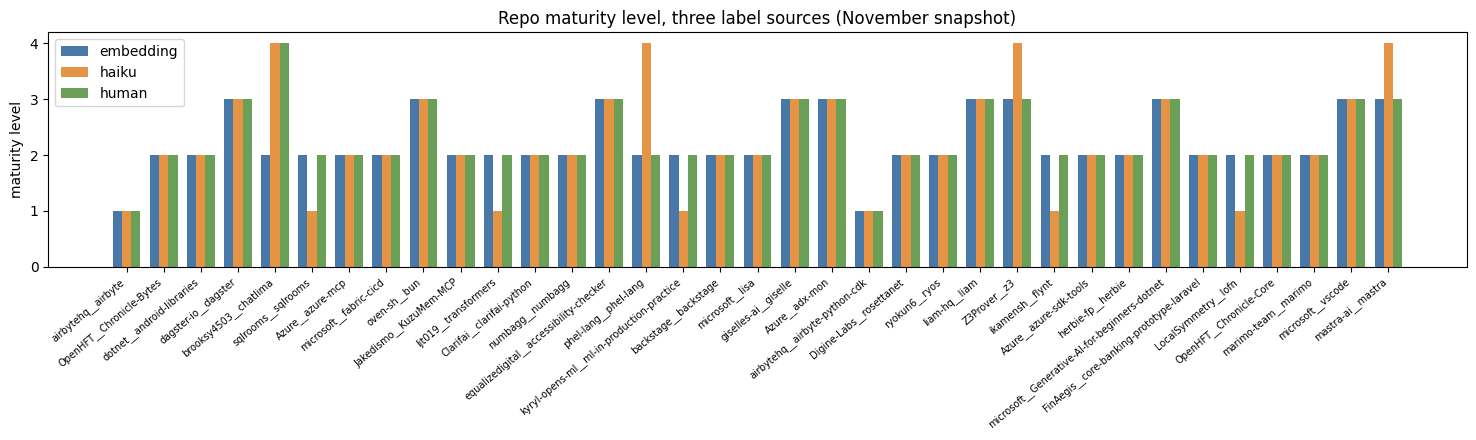

In [8]:
human_map = {(r, p, b): (None if ref == NOT_ARTIFACT else ref)
             for r, p, b, ref in zip(ev["repo"], ev["artifact_path"],
                                     ev["blob_hash"], ev["reference"])}
rows = []
for repo in R_REPOS:
    g = nov_full[nov_full["repo"] == repo]
    keys = list(zip(g["repo"], g["artifact_path"], g["blob_hash"]))
    covered = [k in human_map for k in keys]
    g = g[covered]  # identical subset for all three runs
    keys = [k for k, c in zip(keys, covered) if c]
    lv_emb = aggregate_repo_maturity(fc_list(g, g["cat_emb"])).overall_level
    lv_llm = aggregate_repo_maturity(fc_list(g, g["cat_llm"])).overall_level
    lv_hum = aggregate_repo_maturity(
        fc_list(g, [human_map[k] for k in keys])).overall_level
    rows.append({"repo": repo, "n_files": len(g),
                 "level_embedding": lv_emb, "level_haiku": lv_llm,
                 "level_human": lv_hum,
                 "emb_match": lv_emb == lv_hum, "haiku_match": lv_llm == lv_hum})
repo_eval = pd.DataFrame(rows)
repo_eval = repo_eval.merge(
    repo_table[["repo", "stratum_level_haiku"]], on="repo")
repo_eval.to_csv(HL_DIR / "human_repo_eval.csv", index=False)
print(repo_eval.to_string(index=False))
print(f"\nembedding matches human level: {repo_eval['emb_match'].sum()}/{len(repo_eval)}   "
      f"mean |Δ|: {(repo_eval['level_embedding'] - repo_eval['level_human']).abs().mean():.2f}")
print(f"haiku     matches human level: {repo_eval['haiku_match'].sum()}/{len(repo_eval)}   "
      f"mean |Δ|: {(repo_eval['level_haiku'] - repo_eval['level_human']).abs().mean():.2f}")
print("\nmatch rates per stratum (sample is level-stratified — do not read "
      "the overall rates as population rates):")
print(repo_eval.groupby("stratum_level_haiku")[["emb_match", "haiku_match"]]
      .agg(["sum", "size"]).to_string())
SUMMARY["repo_match_embedding"] = repo_eval["emb_match"].mean()
SUMMARY["repo_match_haiku"] = repo_eval["haiku_match"].mean()

# Chance-corrected and error-magnitude views of the ordinal level agreement, plus
# repo-bootstrap CIs (the repo is the sampling unit here, so a plain bootstrap
# over the 35 repos is the right resampling scheme).
rng = np.random.default_rng(15)
bidx = rng.integers(0, len(repo_eval), size=(10_000, len(repo_eval)))
print()
for name, lvl_col, match_col in (("embedding", "level_embedding", "emb_match"),
                                 ("haiku", "level_haiku", "haiku_match")):
    delta = (repo_eval[lvl_col] - repo_eval["level_human"]).abs()
    SUMMARY[f"repo_off_by_one_{name}"] = float((delta <= 1).mean())
    SUMMARY[f"repo_qwk_{name}"] = cohen_kappa_score(
        repo_eval["level_human"], repo_eval[lvl_col], weights="quadratic")
    m = repo_eval[match_col].to_numpy()
    lo, hi = np.percentile(m[bidx].mean(axis=1), [2.5, 97.5])
    SUMMARY[f"repo_match_{name}_ci"] = (lo, hi)
    k = int(m.sum())
    wlo, whi = wilson_ci(k, len(m))
    print(f"{name:9s}  exact match {k}/{len(m)} = {100 * k / len(m):.0f}% "
          f"(Wilson {100 * wlo:.0f}–{100 * whi:.0f}%, repo-bootstrap "
          f"{100 * lo:.0f}–{100 * hi:.0f}%)  |  within ±1 level: "
          f"{100 * SUMMARY[f'repo_off_by_one_{name}']:.0f}%  |  "
          f"quadratic weighted κ = {SUMMARY[f'repo_qwk_{name}']:.3f}")

x = np.arange(len(repo_eval))
fig, ax = plt.subplots(figsize=(15, 4.5))
for off, col, color in ((-0.25, "level_embedding", "#4878a8"),
                        (0.0, "level_haiku", "#e49444"),
                        (0.25, "level_human", "#6a9f58")):
    ax.bar(x + off, repo_eval[col], width=0.25, color=color,
           label=col.replace("level_", ""))
ax.set_xticks(x, repo_eval["repo"], rotation=40, ha="right", fontsize=7)
ax.set_ylabel("maturity level")
ax.set_title("Repo maturity level, three label sources (November snapshot)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "notebook15_repo_levels.png", dpi=150)
plt.show()

## S6. Summary panel & numeric exports

Every statistic computed above, exported to `human_labeling/paper/` for the
paper's validation subsection — numbers only, no interpretation:

- `summary.json` — all statistics, machine-readable
- `table_agreement.tex` — inter-annotator agreement (α, Fleiss' κ, pairwise κ)
- `table_file_level.tex` — headline file-level metrics, both labelers
- `table_per_category.tex` — per-category precision/recall/F1
- `table_repo_level.tex` — repo-level headline metrics
- `table_repo_eval_full.tex` — the full 35-repo three-way table

Figures live in `validation/figures/notebook15_*.png`. Conclusions are
hand-written in `notebooks/15_human_label_evaluation_conclusions.md`.

In [9]:
import json

PAPER_DIR = HL_DIR / "paper"
PAPER_DIR.mkdir(exist_ok=True)

panel = pd.Series(SUMMARY).to_frame("value")
print(panel.to_string())

with open(PAPER_DIR / "summary.json", "w") as f:
    json.dump({k: (list(v) if isinstance(v, tuple) else v)
               for k, v in SUMMARY.items()}, f, indent=2, default=float)

# --- Minimal booktabs LaTeX writer (chr(92) sidesteps string-escaping layers) ---
BS = chr(92)
ROW = " " + BS + BS

def esc(v):
    return str(v).replace("_", BS + "_").replace("%", BS + "%").replace("&", BS + "&")

def write_tex(df, fname, caption, label):
    lines = [BS + "begin{table}[t]", BS + "centering",
             BS + "caption{" + esc(caption) + "}", BS + "label{" + label + "}",
             BS + "begin{tabular}{l" + "r" * (len(df.columns) - 1) + "}",
             BS + "toprule",
             " & ".join(esc(c) for c in df.columns) + ROW,
             BS + "midrule"]
    lines += [" & ".join(esc(v) for v in r) + ROW
              for r in df.itertuples(index=False)]
    lines += [BS + "bottomrule", BS + "end{tabular}", BS + "end{table}", ""]
    (PAPER_DIR / fname).write_text("\n".join(lines))
    print(f"wrote paper/{fname}")

S = SUMMARY
pc = lambda x: f"{100 * x:.1f}"
ci = lambda k: f"[{100 * S[k][0]:.1f}, {100 * S[k][1]:.1f}]"

tbl_agree = pd.DataFrame([
    ["Krippendorff's alpha (collapsed 10-class)", f"all {S['n_multivote']} items with >=2 votes",
     f"{S['kripp_alpha_10']:.3f}"],
    ["Krippendorff's alpha (raw 11-option)", f"all {S['n_multivote']} items with >=2 votes",
     f"{S['kripp_alpha_11raw']:.3f}"],
    ["Fleiss' kappa", f"triple block (n={S['n_triple']}; small n)",
     f"{S['fleiss_kappa_triple']:.3f}"],
] + [
    [f"Cohen's kappa, pair {p}", f"n={S[f'n_pair_{p}']}, raw agreement {pc(S[f'agree_{p}'])}%",
     f"{S[f'kappa_{p}']:.3f}"]
    for p in ("AB", "AC", "BC")
], columns=["Statistic", "Scope", "Value"])
write_tex(tbl_agree, "table_agreement.tex",
          "Inter-annotator agreement on collapsed 10-class labels (overlap design).",
          "tab:iaa")

tbl_file = pd.DataFrame([
    ["Accuracy vs reference (Wilson 95% CI)",
     f"{pc(S['acc_embedding'])}% {ci('acc_embedding_ci')}",
     f"{pc(S['acc_haiku'])}% {ci('acc_haiku_ci')}"],
    ["Accuracy, repo-cluster bootstrap 95% CI",
     ci("boot_acc_embedding_ci"), ci("boot_acc_haiku_ci")],
    ["Cohen's kappa vs reference",
     f"{S['kappa_vs_human_embedding']:.3f}", f"{S['kappa_vs_human_haiku']:.3f}"],
    ["Balanced accuracy",
     f"{S['balacc_embedding']:.3f}", f"{S['balacc_haiku']:.3f}"],
    ["Macro F1 (classes with support > 0)",
     f"{S['macro_f1_embedding']:.3f}", f"{S['macro_f1_haiku']:.3f}"],
    ["Weighted F1",
     f"{S['weighted_f1_embedding']:.3f}", f"{S['weighted_f1_haiku']:.3f}"],
    [f"Accuracy, majority-vote references (n={S['n_ref_majority']})",
     f"{pc(S['acc_embedding_majority'])}%", f"{pc(S['acc_haiku_majority'])}%"],
    [f"Accuracy, single-rater references (n={S['n_ref_single']})",
     f"{pc(S['acc_embedding_single'])}%", f"{pc(S['acc_haiku_single'])}%"],
], columns=["Metric", "Embedding (AIME)", "Haiku"])
write_tex(tbl_file, "table_file_level.tex",
          f"File-level agreement with the human reference (n={S['n_eval']} items; "
          f"McNemar exact p = {S['mcnemar_p']:.3f}; paired-difference bootstrap 95% CI "
          f"{ci('boot_acc_diff_ci')} pp).",
          "tab:file-level")

pcat = per_cat_eval.rename(columns={
    "category": "Category", "support_human": "n",
    "precision_embedding": "P (emb)", "recall_embedding": "R (emb)",
    "f1_embedding": "F1 (emb)", "precision_haiku": "P (haiku)",
    "recall_haiku": "R (haiku)", "f1_haiku": "F1 (haiku)",
    "low_support": "low n"})
write_tex(pcat, "table_per_category.tex",
          "Per-category precision/recall/F1 against the human reference "
          "(support < 5 flagged).", "tab:per-category")

tbl_repo = pd.DataFrame([
    ["Exact level match (Wilson 95% CI)",
     f"{pc(S['repo_match_embedding'])}%", f"{pc(S['repo_match_haiku'])}%"],
    ["Exact match, repo-bootstrap 95% CI",
     ci("repo_match_embedding_ci"), ci("repo_match_haiku_ci")],
    ["Within +-1 level",
     f"{pc(S['repo_off_by_one_embedding'])}%", f"{pc(S['repo_off_by_one_haiku'])}%"],
    ["Quadratic weighted kappa",
     f"{S['repo_qwk_embedding']:.3f}", f"{S['repo_qwk_haiku']:.3f}"],
], columns=["Metric", "Embedding (AIME)", "Haiku"])
write_tex(tbl_repo, "table_repo_level.tex",
          "Repository maturity level vs the human-derived level through the "
          "production aggregator (35 sampled repositories; stratum-weighted, "
          "not population rates).", "tab:repo-level")

full = repo_eval[["repo", "stratum_level_haiku", "n_files", "level_embedding",
                  "level_haiku", "level_human", "emb_match", "haiku_match"]]
write_tex(full, "table_repo_eval_full.tex",
          "Repository maturity three ways (November 2025 snapshot).",
          "tab:repo-full")

                                                               value
n_repos_dataset                                                  509
n_repos_eligible                                                 268
n_repos_detected                                                 392
kripp_alpha_10                                              0.571615
kripp_alpha_11raw                                           0.571615
n_multivote                                                       67
fleiss_kappa_triple                                         0.838926
n_triple                                                           8
unanimous_triple                                               0.875
kappa_AB                                                    0.648712
n_pair_AB                                                         25
agree_AB                                                        0.76
kappa_AC                                                    0.499083
n_pair_AC                         